In [1]:
# eda04: chain registration transforms, register all exposures to reference (shortest), weighted merge
import math
import numpy as np
import torch
import pickle
import tqdm
from pathlib import Path
from PIL import Image
import enum
from dataclasses import dataclass

class MoonInfoOrigin(enum.Enum):
    DIRECT = 0
    INTERPOLATED = 1

@dataclass
class ImageInfo:
    path: Path
    width: int
    height: int
    avg_brightness: float
    timestamp: float
    exposure_time: float
    moon: tuple[float, float, float] = None
    moon_info_origin: MoonInfoOrigin = None
    moon_pos_std_px: float = None

PKL_DIR = "/home/slavik/tmp"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load eda02 (exposure_groups, opt_results) and eda03 (cross_reg, gamma_by_pair)
with open(f"{PKL_DIR}/eda02.pkl", "rb") as fd:
    exposure_groups = pickle.load(fd)
    reg = pickle.load(fd)
    opt_results = pickle.load(fd)
with open(f"{PKL_DIR}/eda03.pkl", "rb") as fd:
    cross_reg = pickle.load(fd)
    gamma_by_pair = pickle.load(fd)

exposure_times_sorted = sorted(exposure_groups.keys())
# Reference = first (shortest) exposure
t_ref = exposure_times_sorted[0]

def moon_median(group):
    centers_i = [ii.moon[0] for ii in group]
    centers_j = [ii.moon[1] for ii in group]
    radii = [ii.moon[2] for ii in group]
    return (float(np.median(centers_i)), float(np.median(centers_j)), float(np.median(radii)))

moon_ref = moon_median(exposure_groups[t_ref])
print(f"Reference exposure t_ref={t_ref}, moon_ref (i,j,r)={moon_ref}")
print(f"cross_reg pairs: {len(cross_reg)}, gamma_by_pair: {len(gamma_by_pair)}")

Reference exposure t_ref=0.00025, moon_ref (i,j,r)=(1975.8032373889234, 2872.06197001884, 316.0698799244132)
cross_reg pairs: 16, gamma_by_pair: 16


In [2]:
# Recompute per-exposure averaged images (same logic as eda03; not saved there)
def load_grayscale(ii, device):
    with Image.open(ii.path) as img:
        arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 3:
        arr = arr.mean(axis=2)
    return torch.from_numpy(arr).to(device=device, dtype=torch.float32)

def apply_transform_single(img, shift_i, shift_j, angle_deg, device):
    H, W = img.shape
    ci, cj = H / 2.0, W / 2.0
    angle_rad = math.radians(-angle_deg)
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    di = ii - ci - shift_i
    dj = jj - cj - shift_j
    i_src = di * cos_a + dj * sin_a + ci
    j_src = -di * sin_a + dj * cos_a + cj
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

def compute_weighted_average(group, abs_xy, abs_angle_t, device, epsilon=1e-6):
    n = len(group)
    sum_img = None
    sum_mask = None
    for j in range(n):
        img_j = load_grayscale(group[j], device)
        mj_i, mj_j, r_j = group[j].moon[0], group[j].moon[1], group[j].moon[2]
        H, W = img_j.shape
        ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
        jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
        dist = torch.sqrt((ii - mj_i) ** 2 + (jj - mj_j) ** 2)
        # Fill moon with black (radius = moon radius + 2) in this image before warping
        img_j = img_j.clone()
        mask_j = (dist > r_j + 2.0).to(torch.float32)
        x_j = float(abs_xy[j, 0])
        y_j = float(abs_xy[j, 1])
        theta_j_deg = -math.degrees(float(abs_angle_t[j]))
        w_img = apply_transform_single(img_j, x_j, y_j, theta_j_deg, device)
        w_mask = apply_transform_single(mask_j, x_j, y_j, theta_j_deg, device)
        if sum_img is None:
            sum_img = w_img * w_mask
            sum_mask = w_mask.clone()
        else:
            sum_img = sum_img + w_img * w_mask
            sum_mask = sum_mask + w_mask
    avg_img = sum_img / (sum_mask + epsilon)
    avg_mask = sum_mask / n
    return avg_img, avg_mask

avg_images = {}
avg_masks = {}
for exp in tqdm.tqdm(exposure_times_sorted, desc="Averaged images"):
    group = exposure_groups[exp]
    if exp not in opt_results or len(group) < 2:
        continue
    abs_xy = torch.from_numpy(opt_results[exp]["abs_xy"]).to(device)
    abs_angle_t = torch.from_numpy(opt_results[exp]["abs_angle_t"]).to(device)
    avg_images[exp], avg_masks[exp] = compute_weighted_average(group, abs_xy, abs_angle_t, device)

print(f"Built {len(avg_images)} averaged images.")
H_ref, W_ref = next(iter(avg_images.values())).shape
print(f"Reference shape H={H_ref}, W={W_ref}")

Averaged images: 100%|██████████| 17/17 [00:28<00:00,  1.69s/it]

Built 17 averaged images.
Reference shape H=4000, W=6000


In [3]:
# Build ref->k sampling grid by chaining pairwise transforms; scale factor to ref intensity
def ref_to_source_grid(H, W, chain_tuples, device):
    """chain_tuples: list of (shift_i, shift_j, rotation_deg) for (t0,t1), (t1,t2), ..."""
    ci, cj = H / 2.0, W / 2.0
    ii = torch.arange(H, device=device, dtype=torch.float32).view(-1, 1).expand(H, W)
    jj = torch.arange(W, device=device, dtype=torch.float32).view(1, -1).expand(H, W)
    i_cur = ii.clone()
    j_cur = jj.clone()
    for (shift_i, shift_j, rotation_deg) in chain_tuples:
        angle_rad = math.radians(-rotation_deg)
        cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
        di = i_cur - ci - shift_i
        dj = j_cur - cj - shift_j
        i_cur = di * cos_a + dj * sin_a + ci
        j_cur = -di * sin_a + dj * cos_a + cj
    return i_cur, j_cur

def grid_to_normalized_grid(i_src, j_src, H, W):
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    return torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)

def warp_to_ref(img, chain_tuples, H_ref, W_ref, device):
    """Warp img (same or larger concept size) to reference grid using chain ref->source."""
    i_src, j_src = ref_to_source_grid(H_ref, W_ref, chain_tuples, device)
    grid = grid_to_normalized_grid(i_src, j_src, img.shape[0], img.shape[1])
    out = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out.squeeze(0).squeeze(0)

# Scale factor to bring exposure t_k value to t_ref scale: value_ref = value_k * scale_k
# scale_k = (t_ref/t_1)^(1/g1) * (t_1/t_2)^(1/g2) * ... * (t_{k-1}/t_k)^(1/g_k)
def scale_to_ref(exposure_times_sorted, gamma_by_pair, k):
    if k == 0:
        return 1.0
    scale = 1.0
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in gamma_by_pair:
            return None
        g = gamma_by_pair[(t0, t1)]
        scale *= (t0 / t1) ** (1.0 / g)
    return scale

# Exposures that have both avg_image and a chain from ref (consecutive pairs present)
exposures_with_chain = [t_ref]
chain_tuples_by_exp = {t_ref: []}  # ref -> ref is identity
for k in range(1, len(exposure_times_sorted)):
    t_k = exposure_times_sorted[k]
    if t_k not in avg_images:
        continue
    chain = []
    valid = True
    for i in range(k):
        t0, t1 = exposure_times_sorted[i], exposure_times_sorted[i + 1]
        if (t0, t1) not in cross_reg:
            valid = False
            break
        chain.append(cross_reg[(t0, t1)])
    if not valid:
        continue
    chain_tuples_by_exp[t_k] = chain
    exposures_with_chain.append(t_k)

print(f"Exposures in chain: {len(exposures_with_chain)}")

Exposures in chain: 17


In [4]:
# Weight from original (untransformed) value: exp(-((y-0.5)/0.1)^2), y clipped to [0,1]
WEIGHT_SIGMA = 0.2

def weight_from_value(y):
    y = np.clip(y, 0.0, 1.0).astype(np.float64)
    return np.exp(-((y - 0.5) / WEIGHT_SIGMA) ** 2)

# Accumulate weighted average in float64; track valid per exposure for crop
sum_val = np.zeros((H_ref, W_ref), dtype=np.float64)
sum_weight = np.zeros((H_ref, W_ref), dtype=np.float64)
valid_all = None  # intersection of warped valid masks (float, 1 where all exposures cover)
mask_0 = avg_masks[min(avg_masks.keys())] > 0.99
for t_k in tqdm.tqdm(exposures_with_chain, desc="Warp and merge"):
    img_k = avg_images[t_k]
    mask_k = avg_masks[t_k]
    chain = chain_tuples_by_exp[t_k]
    k_idx = exposure_times_sorted.index(t_k)
    scale_k = scale_to_ref(exposure_times_sorted, gamma_by_pair, k_idx)
    if scale_k is None:
        continue

    # Original (unscaled) and scaled value, clipped to [0,1]
    orig = img_k.cpu().numpy().astype(np.float64)
    orig_clip = np.clip(orig, 0.0, 1.0)
    value_scaled = np.clip(orig * scale_k, 0.0, 1.0)
    weight_img = weight_from_value(orig_clip)
    if k_idx > 0:
        weight_img *= (mask_k > 0.99).detach().cpu().numpy()

    # Warp to reference grid
    val_t = torch.from_numpy(value_scaled.astype(np.float32)).to(device)
    w_t = torch.from_numpy(weight_img.astype(np.float32)).to(device)
    valid_t = torch.ones_like(img_k, device=device, dtype=torch.float32)
    warped_val = (warp_to_ref(val_t, chain, H_ref, W_ref, device) * mask_0).cpu().numpy().astype(np.float64)
    warped_w = warp_to_ref(w_t, chain, H_ref, W_ref, device).cpu().numpy().astype(np.float64)
    warped_valid = warp_to_ref(valid_t, chain, H_ref, W_ref, device).cpu().numpy()

    # Only count where this exposure actually covers (avoid border pull-down)
    use = warped_valid >= 0.5
    sum_val += np.where(use, warped_val * warped_w, 0.0)
    sum_weight += np.where(use, warped_w, 0.0)

    if valid_all is None:
        valid_all = warped_valid.copy()
    else:
        valid_all = np.minimum(valid_all, warped_valid)

# Pixels with at least some weight (always true if clipped; defensive)
denom = np.maximum(sum_weight, 1e-20)
composite = (sum_val / denom).astype(np.float64)
print(f"Composite shape {composite.shape}, dtype {composite.dtype}")

Warp and merge: 100%|██████████| 17/17 [00:07<00:00,  2.23it/s]

Composite shape (4000, 6000), dtype float64


In [5]:
# Crop to rectangle where all exposures have valid coverage (valid_all >= 0.5)
VALID_THRESH = 0.5
all_valid_mask = valid_all >= VALID_THRESH
rows = np.any(all_valid_mask, axis=1)
cols = np.any(all_valid_mask, axis=0)
r_lo, r_hi = np.where(rows)[0][[0, -1]]
c_lo, c_hi = np.where(cols)[0][[0, -1]]
composite_crop = composite[r_lo : r_hi + 1, c_lo : c_hi + 1].copy()
# Moon center in ref image; crop offset for moon fill
mi, mj, moon_r = moon_ref
mi_crop = mi - r_lo
mj_crop = mj - c_lo
H_crop, W_crop = composite_crop.shape
print(f"Crop bounds rows [{r_lo},{r_hi}], cols [{c_lo},{c_hi}]; shape {composite_crop.shape}")

# Moon mask (for stats/display; moon already black from compute_weighted_average)
ii = np.arange(H_crop, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W_crop, dtype=np.float64).reshape(1, -1)
dist_sq = (ii - mi_crop) ** 2 + (jj - mj_crop) ** 2
moon_mask = dist_sq <= (moon_r ** 2)

Crop bounds rows [7,3999], cols [0,5989]; shape (3993, 5990)


In [6]:
# Save composite (float64) and a preview image
out_dir = Path(PKL_DIR)
np.save(out_dir / "eda04_composite.npy", composite_crop)
# Preview: normalize to [0,1] for display (or use percentile clip)
v_min = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 1)
v_max = np.percentile(composite_crop[~moon_mask] if np.any(~moon_mask) else composite_crop, 99)
preview = np.clip((composite_crop - v_min) / (v_max - v_min + 1e-9), 0, 1)
Image.fromarray((preview * 255).clip(0, 255).astype(np.uint8)).save(out_dir / "eda04_composite_preview.png")
print(f"Saved {out_dir / 'eda04_composite.npy'} (float64), {out_dir / 'eda04_composite_preview.png'}")

Saved /home/slavik/tmp/eda04_composite.npy (float64), /home/slavik/tmp/eda04_composite_preview.png


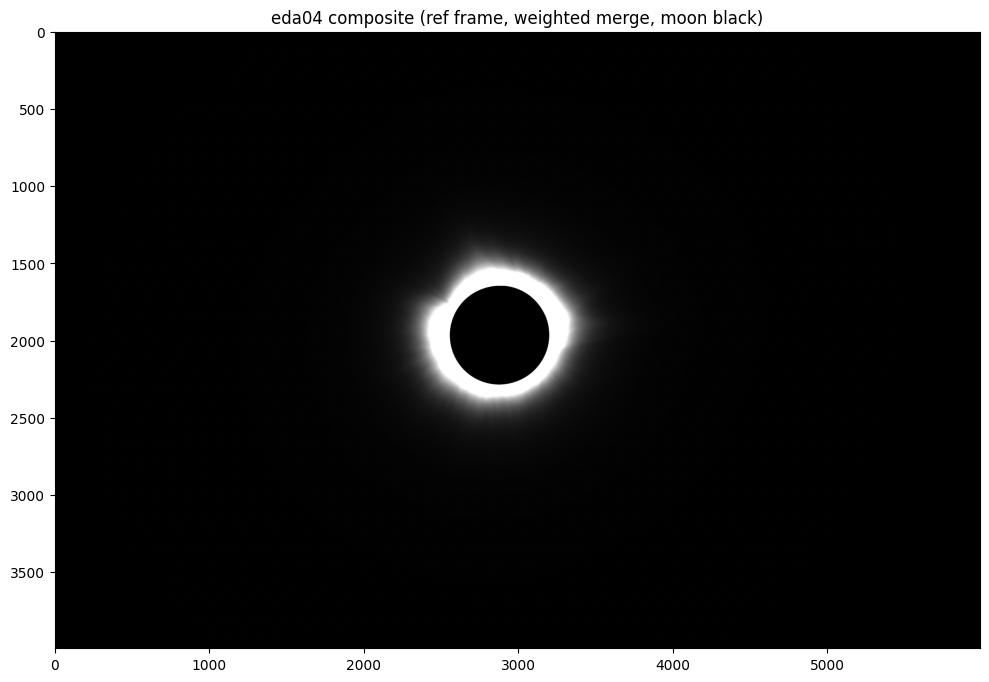

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(composite_crop, cmap="gray", vmin=0, vmax=np.percentile(composite_crop[composite_crop > 0], 99) if np.any(composite_crop > 0) else 1)
ax.set_title("eda04 composite (ref frame, weighted merge, moon black)")
plt.tight_layout()
plt.show()

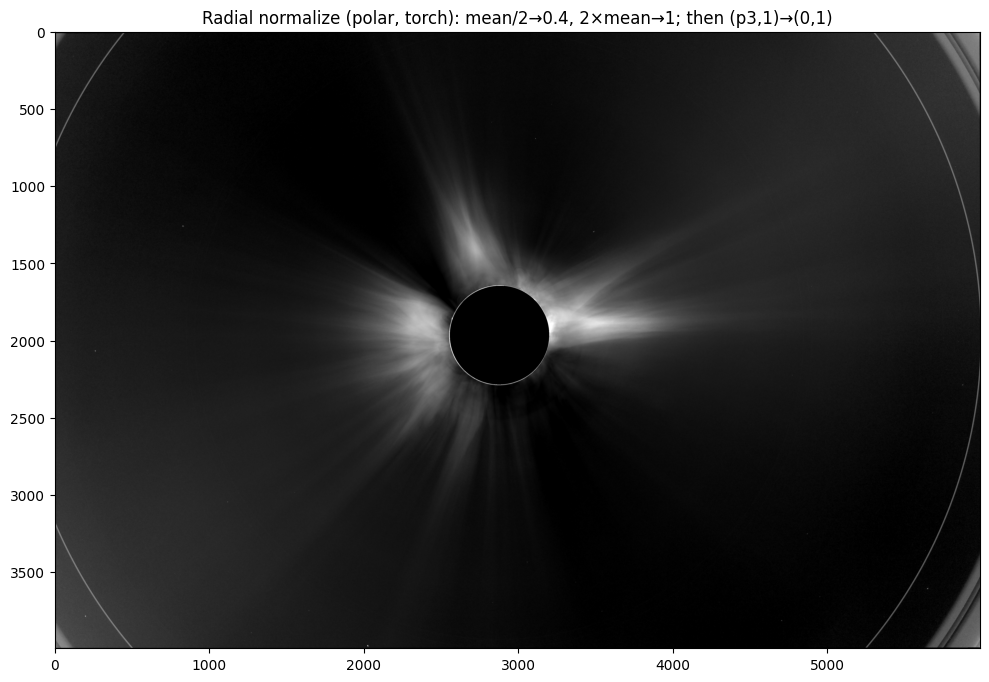

Saved /home/slavik/tmp/eda04_radial_normalize.png


In [8]:
# Same radial normalize (mean/2->0.4, mean->0.4, 2*mean->1; then p3->0, 1->1) via polar view, torch GPU float64
import math
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64

# Center in crop and r_max to farthest corner so polar covers full crop
def dist_to_corners(ci, cj, H, W):
    corners = [(0, 0), (H - 1, 0), (0, W - 1), (H - 1, W - 1)]
    return max(math.sqrt((i - ci) ** 2 + (j - cj) ** 2) for i, j in corners)

def image_to_polar_f64(img, center, radius_min, radius_max, n_r, n_theta, device, dtype):
    """img: (H,W) tensor; returns (polar_image, mask) shape (n_r, n_theta). 1 polar px <= 0.5 cartesian."""
    H, W = img.shape
    ci, cj = center[0], center[1]
    y = torch.arange(n_r, device=device, dtype=dtype).view(-1, 1)
    x = torch.arange(n_theta, device=device, dtype=dtype).view(1, -1)
    # r from radius_max (y=0) down to radius_min (y=n_r-1)
    r = radius_max - y * (radius_max - radius_min) / max(n_r - 1, 1)
    if n_theta > 1:
        theta = 2 * math.pi * x / (n_theta - 1)
    else:
        theta = torch.zeros_like(x, device=device, dtype=dtype)
    i_src = ci + r * torch.sin(theta)
    j_src = cj + r * torch.cos(theta)
    j_norm = 2.0 * j_src / (W - 1) - 1.0 if W > 1 else torch.zeros_like(j_src)
    i_norm = 2.0 * i_src / (H - 1) - 1.0 if H > 1 else torch.zeros_like(i_src)
    grid = torch.stack([j_norm, i_norm], dim=-1).unsqueeze(0)
    polar = torch.nn.functional.grid_sample(
        img.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    mask = (i_src >= 0) & (i_src < H) & (j_src >= 0) & (j_src < W)
    return polar, mask.squeeze(-1) if mask.dim() > 2 else mask

def polar_to_cartesian_f64(polar, center, radius_min, radius_max, H, W, device, dtype):
    """polar (n_r, n_theta) -> cartesian (H, W). Bilinear; zeros outside [radius_min, radius_max]."""
    n_r, n_theta = polar.shape
    ci, cj = center[0], center[1]
    i = torch.arange(H, device=device, dtype=dtype).view(-1, 1)
    j = torch.arange(W, device=device, dtype=dtype).view(1, -1)
    r = torch.sqrt((i - ci) ** 2 + (j - cj) ** 2)
    theta = torch.atan2(i - ci, j - cj)
    theta = torch.where(theta < 0, theta + 2 * math.pi, theta)
    y_polar = (radius_max - r) * (n_r - 1) / max(radius_max - radius_min, 1e-9)
    x_polar = theta / (2 * math.pi) * (n_theta - 1) if n_theta > 1 else torch.zeros_like(theta)
    x_norm = 2.0 * x_polar / (n_theta - 1) - 1.0 if n_theta > 1 else torch.zeros_like(x_polar)
    y_norm = 2.0 * y_polar / (n_r - 1) - 1.0 if n_r > 1 else torch.zeros_like(y_polar)
    grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(0)
    out = torch.nn.functional.grid_sample(
        polar.unsqueeze(0).unsqueeze(0), grid, mode="bilinear", padding_mode="zeros", align_corners=True
    ).squeeze(0).squeeze(0)
    valid = (r >= radius_min) & (r <= radius_max)
    return torch.where(valid, out, torch.zeros_like(out))

# Input: composite_crop, moon center, moon_r (from previous cells)
img = torch.from_numpy(composite_crop).to(device=device, dtype=dtype)
center = (float(mi_crop), float(mj_crop))
radius_min = 0.0
radius_max = dist_to_corners(mi_crop, mj_crop, H_crop, W_crop)
# Polar resolution: 1 polar px <= 0.5 cartesian px
n_r = max(int(math.ceil(2 * (radius_max - radius_min))) + 1, 2)
n_theta = max(int(math.ceil(4 * math.pi * radius_max)) + 1, 2)

polar_img, valid = image_to_polar_f64(img, center, radius_min, radius_max, n_r, n_theta, device, dtype)
# valid = True where polar sample is inside crop (same as polar view of ones_like)

# Radial coordinate for each row (y=0 -> r_max, y=n_r-1 -> r_min)
r_row = radius_max - torch.arange(n_r, device=device, dtype=dtype) * (radius_max - radius_min) / max(n_r - 1, 1)
r_min_moon = moon_r + 2.0

# Mean per row (only where valid)
sum_v = (polar_img * valid).sum(dim=1)
sum_n = valid.sum(dim=1).clamp(min=1e-20)
mean_row = sum_v / sum_n
mx = mean_row[torch.isfinite(mean_row)].max().item()
mean_row = mean_row.clone()
for i in range(n_r):
    if r_row[i].item() < r_min_moon and mean_row[i].item() < 0.999 * mx:
        mean_row[i] = mx
mean_polar_2d = mean_row.unsqueeze(1).expand(n_r, n_theta)
mean_at = polar_to_cartesian_f64(mean_polar_2d, center, radius_min, radius_max, H_crop, W_crop, device, dtype)

# Piecewise: mean/2->0, mean->0.4, 2*mean->1
valid_mask = torch.isfinite(mean_at) & (mean_at > 0)
display_t = torch.zeros_like(img, device=device, dtype=dtype)
v = img[valid_mask]
m = mean_at[valid_mask]
mask1 = (v > m / 2) & (v <= m)
mask2 = (v > m) & (v <= 2 * m)
mask3 = v > 2 * m
display_t[valid_mask] = torch.where(mask1, 0.4 * (v - m / 2) / (m / 2).clamp(min=1e-9), torch.zeros_like(v))
display_t[valid_mask] = torch.where(mask2, 0.4 + 0.6 * (v - m) / m.clamp(min=1e-9), display_t[valid_mask])
display_t[valid_mask] = torch.where(mask3, torch.ones_like(v), display_t[valid_mask])

# p3 in polar
polar_display, _ = image_to_polar_f64(display_t, center, radius_min, radius_max, n_r, n_theta, device, dtype)
p3_row = torch.full((n_r,), float("nan"), device=device, dtype=dtype)
for i in range(n_r):
    vals = polar_display[i][valid[i]]
    if vals.numel() > 0:
        p3_row[i] = torch.quantile(vals.float(), 0.03).to(dtype)
p3_radius_bins = 10.0
bin_centers_t = torch.arange(n_r, device=device, dtype=dtype)
p3_smooth = torch.full_like(p3_row, float("nan"))
for i in range(n_r):
    w = (torch.abs(bin_centers_t - i) <= p3_radius_bins) & torch.isfinite(p3_row)
    if w.any():
        p3_smooth[i] = torch.nanmedian(p3_row[w])
p3_polar_2d = p3_smooth.unsqueeze(1).expand(n_r, n_theta)
p3_at = polar_to_cartesian_f64(p3_polar_2d, center, radius_min, radius_max, H_crop, W_crop, device, dtype)
p3_at = torch.nan_to_num(p3_at, nan=0.0)

# (p3, 1) -> (0, 1)
span = (1.0 - p3_at).clamp(min=1e-9)
display_t = ((display_t - p3_at) / span).clamp(0.0, 1.0)
display_t[torch.from_numpy(moon_mask).to(device=device)] = 0.0

display_np = display_t.cpu().numpy()
display = display_np  # for downstream cells (sharpening, etc.)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(display, cmap="gray", vmin=0, vmax=1)
ax.set_title("Radial normalize (polar, torch): mean/2→0.4, 2×mean→1; then (p3,1)→(0,1)")
plt.tight_layout()
plt.show()
Image.fromarray((display * 255).clip(0, 255).astype(np.uint8)).save(Path(PKL_DIR) / "eda04_radial_normalize.png")
print(f"Saved {Path(PKL_DIR) / 'eda04_radial_normalize.png'}")

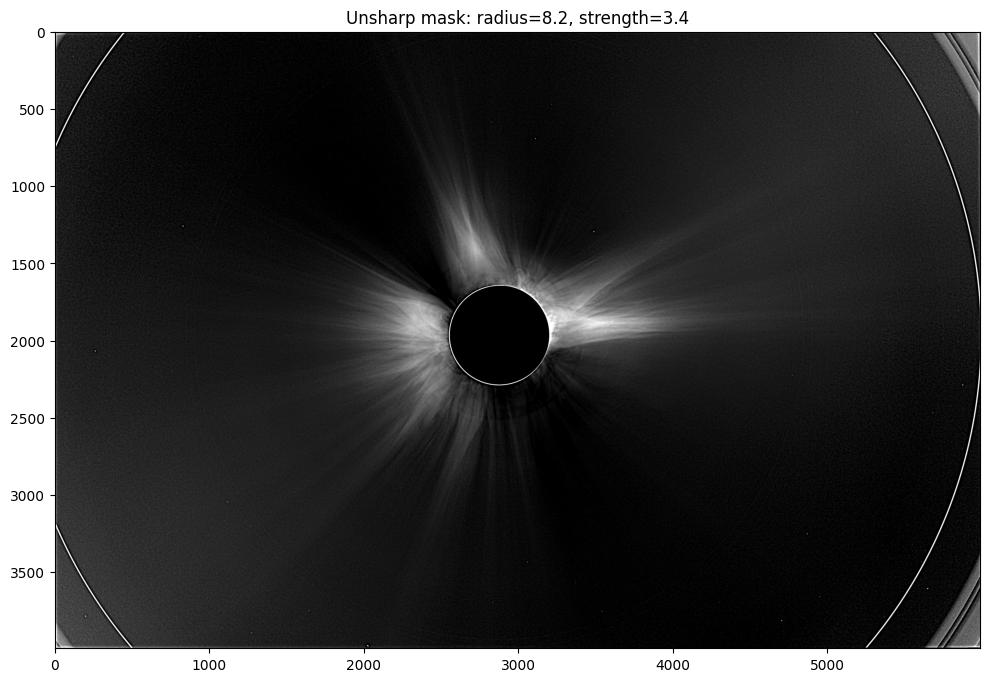

In [9]:
# Unsharp mask: sharpen display with radius (Gaussian sigma) 4.2, strength 3.4
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from PIL import Image

radius = 8.2   # Gaussian sigma for blur (pixels)
strength = 3.4
blurred = gaussian_filter(display, sigma=radius, mode="nearest")
sharpened = display + strength * (display - blurred)
sharpened = np.clip(sharpened, 0.0, 1.0)
sharpened[moon_mask] = 0.0

Image.fromarray((sharpened * 255).clip(0, 255).astype(np.uint8)).save("/home/slavik/tmp/eda04_radial_normalize_sharpen.png")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(sharpened, cmap="gray", vmin=0, vmax=1)
ax.set_title("Unsharp mask: radius=8.2, strength=3.4")
plt.tight_layout()
plt.show()

Second loop for X=10: 100%|██████████| 3717/3717 [00:00<00:00, 1995932.40it/s]


Saved /home/slavik/tmp/eda04_sharpen_p10_scale.png


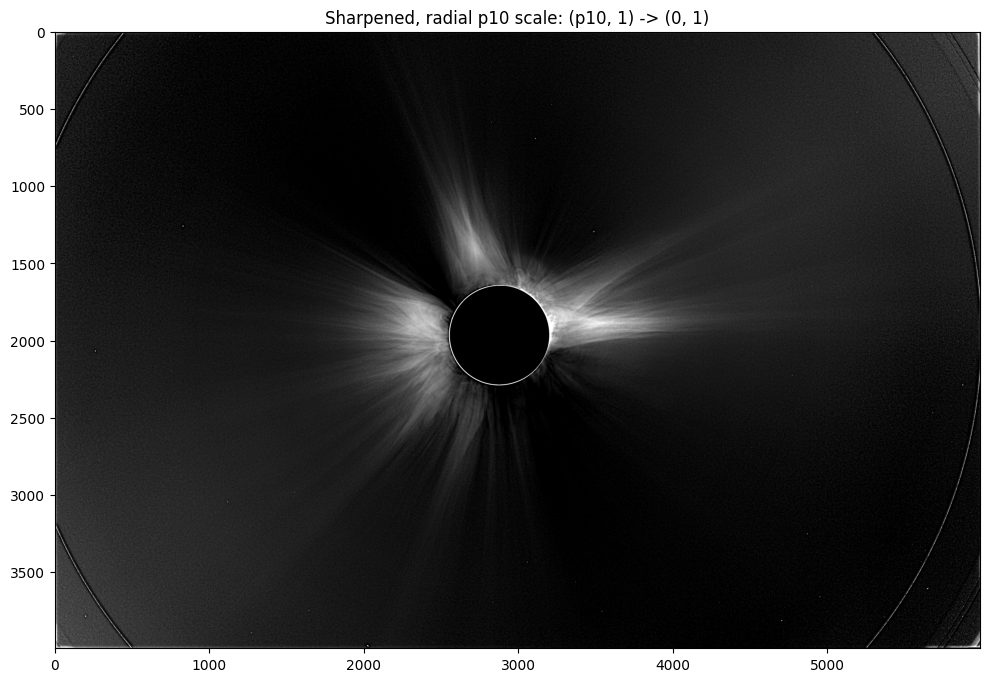

In [10]:
# Moon-centered radial pX profile: scale (pX, 1) -> (0, 1) per pixel; X in [1, 2, 5, 10, 20]
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

img = sharpened
H, W = img.shape
ii = np.arange(H, dtype=np.float64).reshape(-1, 1)
jj = np.arange(W, dtype=np.float64).reshape(1, -1)
dist = np.sqrt((ii - mi_crop) ** 2 + (jj - mj_crop) ** 2)
d_flat = dist.ravel()
v_flat = img.ravel()

# Radial profile with 1 px bins (fine, "no binning" in the sense of continuous lookup)
bin_width = 1.0
d_max = int(np.ceil(dist.max())) + 1
bins = np.arange(0, d_max + 1e-9, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_bins = len(bin_centers)

for X in [10]:
    pX_bin = np.full(n_bins, np.nan)
    for i in tqdm.tqdm(range(len(bins) - 1), desc=f'First loop for {X=}'):
        in_bin = (d_flat >= bins[i]) & (d_flat < bins[i + 1])
        if in_bin.sum() > 0:
            pX_bin[i] = np.percentile(v_flat[in_bin], X)
    # Forward-fill empty bins so pX_at has no NaN
    last = 0.0
    for i in tqdm.tqdm(range(n_bins), desc=f'Second loop for {X=}'):
        if np.isfinite(pX_bin[i]):
            last = pX_bin[i]
        else:
            pX_bin[i] = last
    bin_idx = np.searchsorted(bins, dist.ravel(), side="right") - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    pX_at = pX_bin[bin_idx].reshape(H, W)
    span = np.maximum(1.0 - pX_at, 1e-9)
    scaled = (img - pX_at) / span
    scaled = np.clip(scaled, 0.0, 1.0)
    scaled[moon_mask] = 0.0

    out_path = Path(PKL_DIR) / f"eda04_sharpen_p{X}_scale.png"
    Image.fromarray((scaled * 255).clip(0, 255).astype(np.uint8)).save(out_path)
    print(f"Saved {out_path}")

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(scaled, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Sharpened, radial p{X} scale: (p{X}, 1) -> (0, 1)")
    plt.tight_layout()
    plt.show()